# Task 1 and Task 2: Fold-Safe Efficient TSFresh Pipeline

This notebook restarts the implementation from the strict protocol requested for every fold:

1. Use only the fold training split to fit label-aware preprocessing/feature selection and classifiers.
2. Use the validation split only for hyperparameter selection.
3. Use the test split only once for final evaluation.

EfficientFCParameters are fixed TSFresh calculators, so their per-subject values can be cached without learning from validation or test labels. The learned steps are the TSFresh relevance selector, imputer/scaler/selector, and classifier, and those are fit on the training split only.

In [1]:
from pathlib import Path
import ast
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
TABLES = ROOT / "results" / "tables"
FIGURES = ROOT / "results" / "figures"
FOLD_FEATURES = ROOT / "results" / "fold_features"
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

## Optional Pipeline Run

Leave `RUN_PIPELINE = False` when the Efficient run has already produced results. Set it to `True` only when you want the notebook to rerun the complete experiment.

In [2]:
RUN_PIPELINE = False

pipeline_command = [
    sys.executable,
    "scripts/run_deliverable2.py",
    "--feature-set", "efficient",
    "--selection-metric", "f1",
    "--max-epochs", "6",
    "--patience", "2",
    "--batch-size", "16",
    "--deep-k-features", "100", "200", "400",
    "--deep-learning-rates", "0.0003", "0.0008",
    "--deep-weight-decays", "0.0001", "0.001",
    "--fresh-fdr-levels", "0.05", "0.1", "0.2", "0.5",
]

if RUN_PIPELINE:
    subprocess.run(pipeline_command, check=True)

" ".join(pipeline_command)

'/Users/keshavperiwal/Documents Local/Semester 2/Project Time Series/Data/.venv/bin/python scripts/run_deliverable2.py --feature-set efficient --selection-metric f1 --max-epochs 6 --patience 2 --batch-size 16 --deep-k-features 100 200 400 --deep-learning-rates 0.0003 0.0008 --deep-weight-decays 0.0001 0.001 --fresh-fdr-levels 0.05 0.1 0.2 0.5'

### Optional Neural Grid Refresh

After the full fold-safe run exists, this faster command reruns only the feature-vector neural models with the expanded grid and merges them back with the existing classical and TSFresh-selection results.

In [3]:
RUN_NEURAL_GRID_REFRESH = False

neural_grid_command = [
    sys.executable,
    "scripts/run_deliverable2.py",
    "--feature-set", "efficient",
    "--only-feature-neural",
    "--selection-metric", "f1",
    "--max-epochs", "6",
    "--patience", "2",
    "--batch-size", "16",
    "--deep-k-features", "100", "200", "400",
    "--deep-learning-rates", "0.0003", "0.0008",
    "--deep-weight-decays", "0.0001", "0.001",
]

if RUN_NEURAL_GRID_REFRESH:
    subprocess.run(neural_grid_command, check=True)

" ".join(neural_grid_command)

'/Users/keshavperiwal/Documents Local/Semester 2/Project Time Series/Data/.venv/bin/python scripts/run_deliverable2.py --feature-set efficient --only-feature-neural --selection-metric f1 --max-epochs 6 --patience 2 --batch-size 16 --deep-k-features 100 200 400 --deep-learning-rates 0.0003 0.0008 --deep-weight-decays 0.0001 0.001'

## Task 1: Demographics and Fold Distribution

Null values in demographics are handled before summarization: numeric fields are filled by group median and then global median; categorical fields are filled as `Unknown`.

In [ ]:
manifest_path = TABLES / "fold_manifest.csv"
if manifest_path.exists():
    manifest = pd.read_csv(manifest_path)
else:
    rows = []
    for fold_dir in sorted((ROOT / "splits").glob("Fold_*")):
        for split in ["training", "validation", "test"]:
            for path in sorted((fold_dir / split).glob("*.txt")):
                sid = path.stem.rsplit("_", 1)[0]
                group = "Control" if sid[2:4] == "Co" else "Patient"
                rows.append({"fold": fold_dir.name, "split": split, "subject_id": sid, "group": group, "file": str(path.relative_to(ROOT))})
    manifest = pd.DataFrame(rows)

demo = pd.read_excel(ROOT / "demographics.xls", engine="xlrd")
demo = demo[demo["ID"].isin(manifest["subject_id"].unique())].copy()
demo["Group"] = demo["Group"].replace({"CO": "Control", "PD": "Patient"})

numeric_columns = demo.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = [c for c in demo.columns if c not in numeric_columns]
for column in numeric_columns:
    demo[column] = demo.groupby("Group")[column].transform(lambda s: s.fillna(s.median()))
    demo[column] = demo[column].fillna(demo[column].median())
for column in categorical_columns:
    demo[column] = demo[column].fillna("Unknown")

demographics_summary = (
    demo.groupby("Group", as_index=False)
    .agg(
        subjects=("ID", "count"),
        age_mean=("Age", "mean"),
        age_sd=("Age", "std"),
        height_mean=("Height", "mean"),
        weight_mean=("Weight", "mean"),
    )
    .round(2)
)
display(demographics_summary)

fold_distribution = (
    manifest.groupby(["fold", "split", "group"], as_index=False)
    .size()
    .rename(columns={"size": "subjects"})
    .sort_values(["fold", "split", "group"])
)
display(fold_distribution)

KeyError: "Label(s) ['Height', 'Weight'] do not exist"

## Task 1: Efficient TSFresh Feature Matrices

The matrices below should contain one row per subject per fold split. They are split-specific artifacts assembled from fixed Efficient TSFresh feature calculations. No PCA, scaler, TSFresh feature selection, or classifier is fit outside the training split.

In [6]:
audit_path = TABLES / "deliverable2_fold_safe_feature_audit.csv"
if audit_path.exists():
    audit = pd.read_csv(audit_path)
    display(audit)
else:
    print("Feature audit not found yet. Run the pipeline cell after extraction finishes.")

,fold,split,rows,feature_columns,path,feature_set,extraction_protocol
0,Fold_1,training,60,84430,results/fold_features/Fold_1/training_feature_...,efficient,fixed TSFresh calculators cached per subject; ...
1,Fold_1,validation,20,84430,results/fold_features/Fold_1/validation_featur...,efficient,fixed TSFresh calculators cached per subject; ...
2,Fold_1,test,20,84430,results/fold_features/Fold_1/test_feature_matr...,efficient,fixed TSFresh calculators cached per subject; ...
3,Fold_2,training,60,84430,results/fold_features/Fold_2/training_feature_...,efficient,fixed TSFresh calculators cached per subject; ...
4,Fold_2,validation,20,84430,results/fold_features/Fold_2/validation_featur...,efficient,fixed TSFresh calculators cached per subject; ...
5,Fold_2,test,20,84430,results/fold_features/Fold_2/test_feature_matr...,efficient,fixed TSFresh calculators cached per subject; ...
6,Fold_3,training,60,84430,results/fold_features/Fold_3/training_feature_...,efficient,fixed TSFresh calculators cached per subject; ...
7,Fold_3,validation,20,84430,results/fold_features/Fold_3/validation_featur...,efficient,fixed TSFresh calculators cached per subject; ...
8,Fold_3,test,20,84430,results/fold_features/Fold_3/test_feature_matr...,efficient,fixed TSFresh calculators cached per subject; ...
9,Fold_4,training,60,84430,results/fold_features/Fold_4/training_feature_...,efficient,fixed TSFresh calculators cached per subject; ...


## Task 1: PCA and t-SNE with Train-Fitted Z-Score Normalization

For visualization, this cell uses Fold_1 training features. The imputer and z-score scaler are fit only on the training feature matrix before PCA/t-SNE.

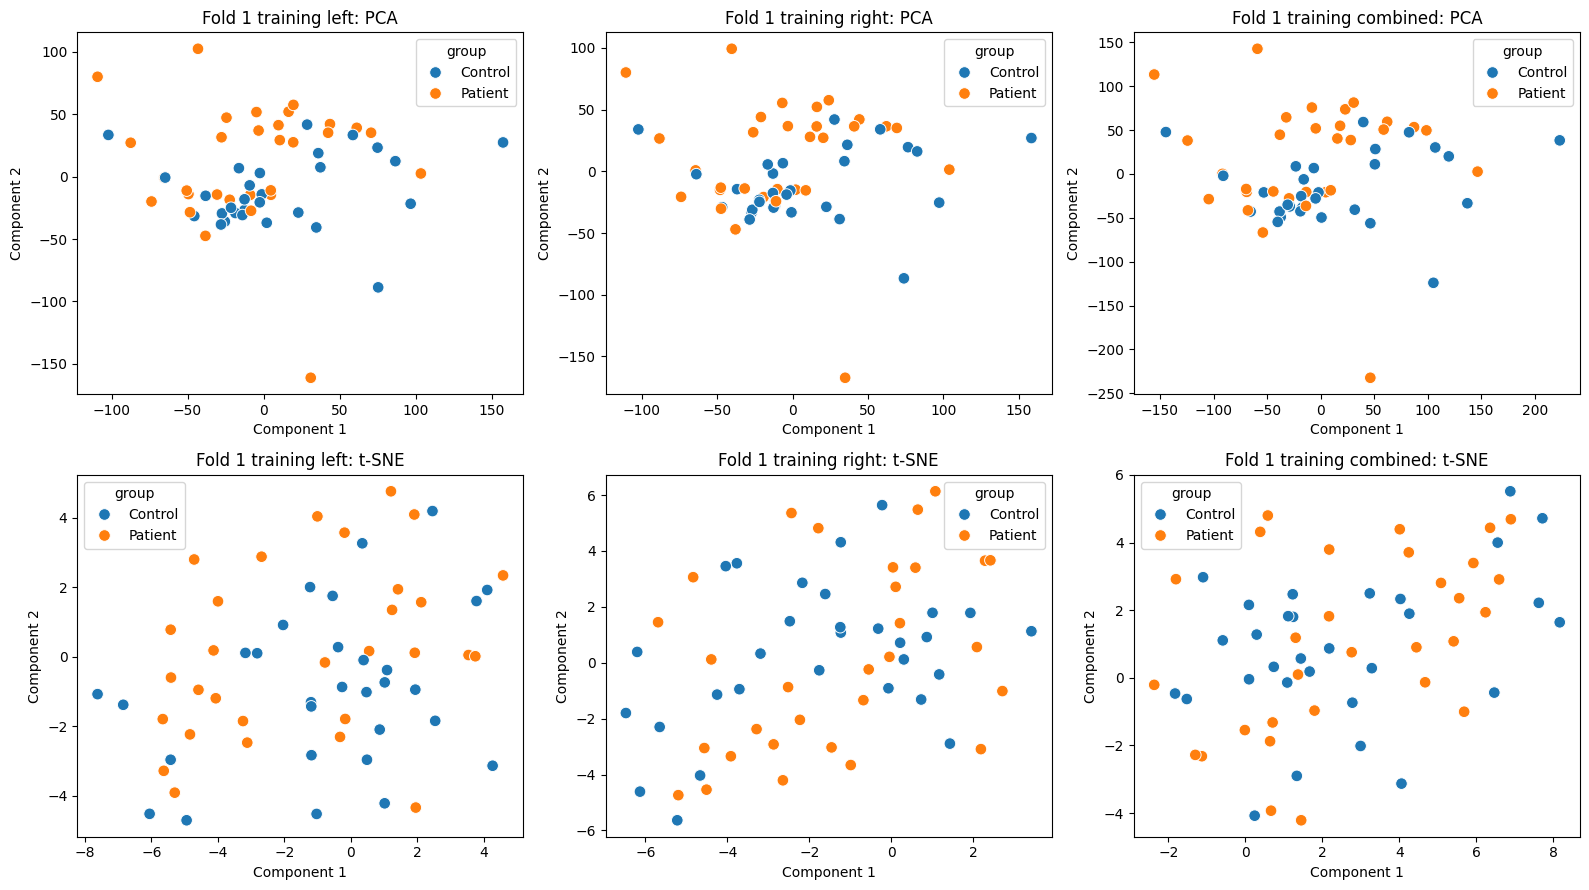

In [7]:
def feature_columns(matrix, scope):
    if scope == "left":
        return [c for c in matrix.columns if c.startswith("left__")]
    if scope == "right":
        return [c for c in matrix.columns if c.startswith("right__")]
    if scope == "combined":
        return [c for c in matrix.columns if c.startswith(("left__", "right__"))]
    if scope == "enhanced":
        return [c for c in matrix.columns if c.startswith(("left__", "right__", "asym__", "gait__", "wavelet__"))]
    raise ValueError(scope)

def plot_embedding(matrix, scope, method="pca"):
    columns = feature_columns(matrix, scope)
    x = matrix[columns].replace([np.inf, -np.inf], np.nan)
    x = SimpleImputer(strategy="median").fit_transform(x)
    x = StandardScaler().fit_transform(x)
    if method == "pca":
        embedding = PCA(n_components=2, random_state=42).fit_transform(x)
        title = f"Fold 1 training {scope}: PCA"
    else:
        perplexity = min(20, max(5, len(matrix) // 4))
        embedding = TSNE(n_components=2, perplexity=perplexity, init="pca", learning_rate="auto", random_state=42).fit_transform(x)
        title = f"Fold 1 training {scope}: t-SNE"
    plot_df = pd.DataFrame({"x": embedding[:, 0], "y": embedding[:, 1], "group": matrix["group"]})
    sns.scatterplot(data=plot_df, x="x", y="y", hue="group", s=70)
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.tight_layout()

fold1_train = FOLD_FEATURES / "Fold_1" / "training_feature_matrix_efficient.csv"
if fold1_train.exists():
    matrix = pd.read_csv(fold1_train)
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, scope in zip(axes[0], ["left", "right", "combined"]):
        plt.sca(ax)
        plot_embedding(matrix, scope, "pca")
    for ax, scope in zip(axes[1], ["left", "right", "combined"]):
        plt.sca(ax)
        plot_embedding(matrix, scope, "tsne")
    plt.show()
else:
    print(f"Waiting for {fold1_train}. Run or finish the Efficient pipeline first.")

## Task 2: Fold-Safe Model Evaluation

Metrics are averaged across the five independent test folds. Required reporting metrics are Accuracy, Sensitivity, Specificity, and AUC.

In [8]:
summary_path = TABLES / "deliverable2_model_summary.csv"
if summary_path.exists():
    summary = pd.read_csv(summary_path)
    metric_columns = [
        "family", "scope", "model",
        "validation_accuracy_mean", "validation_auc_mean",
        "test_accuracy_mean", "test_sensitivity_mean", "test_specificity_mean", "test_auc_mean",
        "test_f1_mean",
    ]
    display(summary[metric_columns].sort_values(["scope", "test_accuracy_mean", "test_auc_mean"], ascending=[True, False, False]))
else:
    print("Model summary not found yet. Run the pipeline first.")

,family,scope,model,validation_accuracy_mean,validation_auc_mean,test_accuracy_mean,test_sensitivity_mean,test_specificity_mean,test_auc_mean,test_f1_mean
0,feature_classical,combined,linear_svm,0.88,0.886,0.83,0.86,0.80,0.892,0.834124
1,feature_classical,combined,random_forest,0.87,0.898,0.82,0.84,0.80,0.892,0.824539
2,feature_classical_tsfresh,combined,random_forest_fresh,0.84,0.892,0.82,0.84,0.80,0.874,0.820191
3,feature_classical,combined,svm_rbf,0.88,0.900,0.81,0.86,0.76,0.888,0.818964
4,feature_classical_tsfresh,combined,linear_svm_fresh,0.84,0.898,0.78,0.74,0.82,0.892,0.753298
5,feature_neural,combined,patchtst,0.83,0.886,0.78,0.82,0.74,0.866,0.789426
6,feature_neural,combined,gru,0.78,0.830,0.77,0.78,0.76,0.826,0.767486
7,feature_classical_tsfresh,combined,svm_rbf_fresh,0.86,0.898,0.76,0.76,0.76,0.836,0.758146
8,feature_neural,combined,lstm,0.78,0.830,0.72,0.66,0.78,0.852,0.685373
9,feature_neural,combined,resnet1d,0.81,0.842,0.72,0.74,0.70,0.814,0.724349


## TSFresh Feature Selection Usefulness Check

This table compares the standard train-fitted `SelectKBest(f_classif)` path with TSFresh's own `select_features` relevance selector across the same folds and scopes.

In [9]:
comparison_path = TABLES / "deliverable2_feature_selection_comparison.csv"
if comparison_path.exists():
    comparison = pd.read_csv(comparison_path)
    display(
        comparison[
            [
                "selector", "scope", "model",
                "test_accuracy_mean", "test_sensitivity_mean", "test_specificity_mean", "test_auc_mean", "test_f1_mean",
            ]
        ].sort_values(["scope", "selector", "test_accuracy_mean"], ascending=[True, True, False])
    )
else:
    print("TSFresh selector comparison not found yet. It will be written by the pipeline.")

,selector,scope,model,test_accuracy_mean,test_sensitivity_mean,test_specificity_mean,test_auc_mean,test_f1_mean
0,sklearn.SelectKBest,combined,linear_svm,0.83,0.86,0.80,0.892,0.834124
1,sklearn.SelectKBest,combined,random_forest,0.82,0.84,0.80,0.892,0.824539
3,sklearn.SelectKBest,combined,svm_rbf,0.81,0.86,0.76,0.888,0.818964
2,tsfresh.select_features,combined,random_forest_fresh,0.82,0.84,0.80,0.874,0.820191
4,tsfresh.select_features,combined,linear_svm_fresh,0.78,0.74,0.82,0.892,0.753298
5,tsfresh.select_features,combined,svm_rbf_fresh,0.76,0.76,0.76,0.836,0.758146
7,sklearn.SelectKBest,enhanced,random_forest,0.83,0.84,0.82,0.896,0.831907
8,sklearn.SelectKBest,enhanced,linear_svm,0.80,0.86,0.74,0.894,0.811971
9,sklearn.SelectKBest,enhanced,svm_rbf,0.80,0.80,0.80,0.892,0.799690
6,tsfresh.select_features,enhanced,random_forest_fresh,0.83,0.82,0.84,0.901,0.819661


## Neural Feature-Vector Hyperparameter Grid

Neural models use the extracted Efficient feature vector rather than raw signals. Validation selects among the configured `k_features`, learning-rate, and weight-decay grid, plus the best epoch via early stopping.

In [10]:
metrics_path = TABLES / "deliverable2_feature_neural_fold_metrics.csv"
if metrics_path.exists():
    neural = pd.read_csv(metrics_path)
    neural_best_params = neural[["fold", "scope", "model", "best_params", "test_accuracy", "test_sensitivity", "test_specificity", "test_auc"]].copy()
    neural_best_params["parsed_best_params"] = neural_best_params["best_params"].map(ast.literal_eval)
    neural_best_params["k_features"] = neural_best_params["parsed_best_params"].map(lambda d: d.get("k_features"))
    neural_best_params["best_epoch"] = neural_best_params["parsed_best_params"].map(lambda d: d.get("best_epoch"))
    display(neural_best_params.drop(columns=["best_params", "parsed_best_params"]).sort_values(["scope", "model", "fold"]))
else:
    print("Neural fold metrics not found yet. They will be written by the pipeline.")

,fold,scope,model,test_accuracy,test_sensitivity,test_specificity,test_auc,k_features,best_epoch
10,Fold_1,combined,gru,0.80,0.6,1.0,0.92,100,4
26,Fold_2,combined,gru,0.85,1.0,0.7,0.87,100,4
42,Fold_3,combined,gru,0.65,0.5,0.8,0.64,100,6
58,Fold_4,combined,gru,0.90,0.8,1.0,0.95,200,6
74,Fold_5,combined,gru,0.65,1.0,0.3,0.75,400,4
...,...,...,...,...,...,...,...,...,...
4,Fold_1,right,resnet1d,0.90,0.9,0.9,0.93,100,2
20,Fold_2,right,resnet1d,0.70,0.9,0.5,0.72,100,3
36,Fold_3,right,resnet1d,0.75,0.9,0.6,0.85,400,5
52,Fold_4,right,resnet1d,0.80,0.8,0.8,0.89,100,2


## Best Models and Confusion Matrices

,scope,model,test_accuracy_mean,test_sensitivity_mean,test_specificity_mean,test_auc_mean
0,combined,linear_svm,0.83,0.86,0.80,0.892
1,enhanced,random_forest_fresh,0.83,0.82,0.84,0.901
2,left,linear_svm_fresh,0.82,0.82,0.82,0.912
3,right,random_forest,0.83,0.86,0.80,0.902


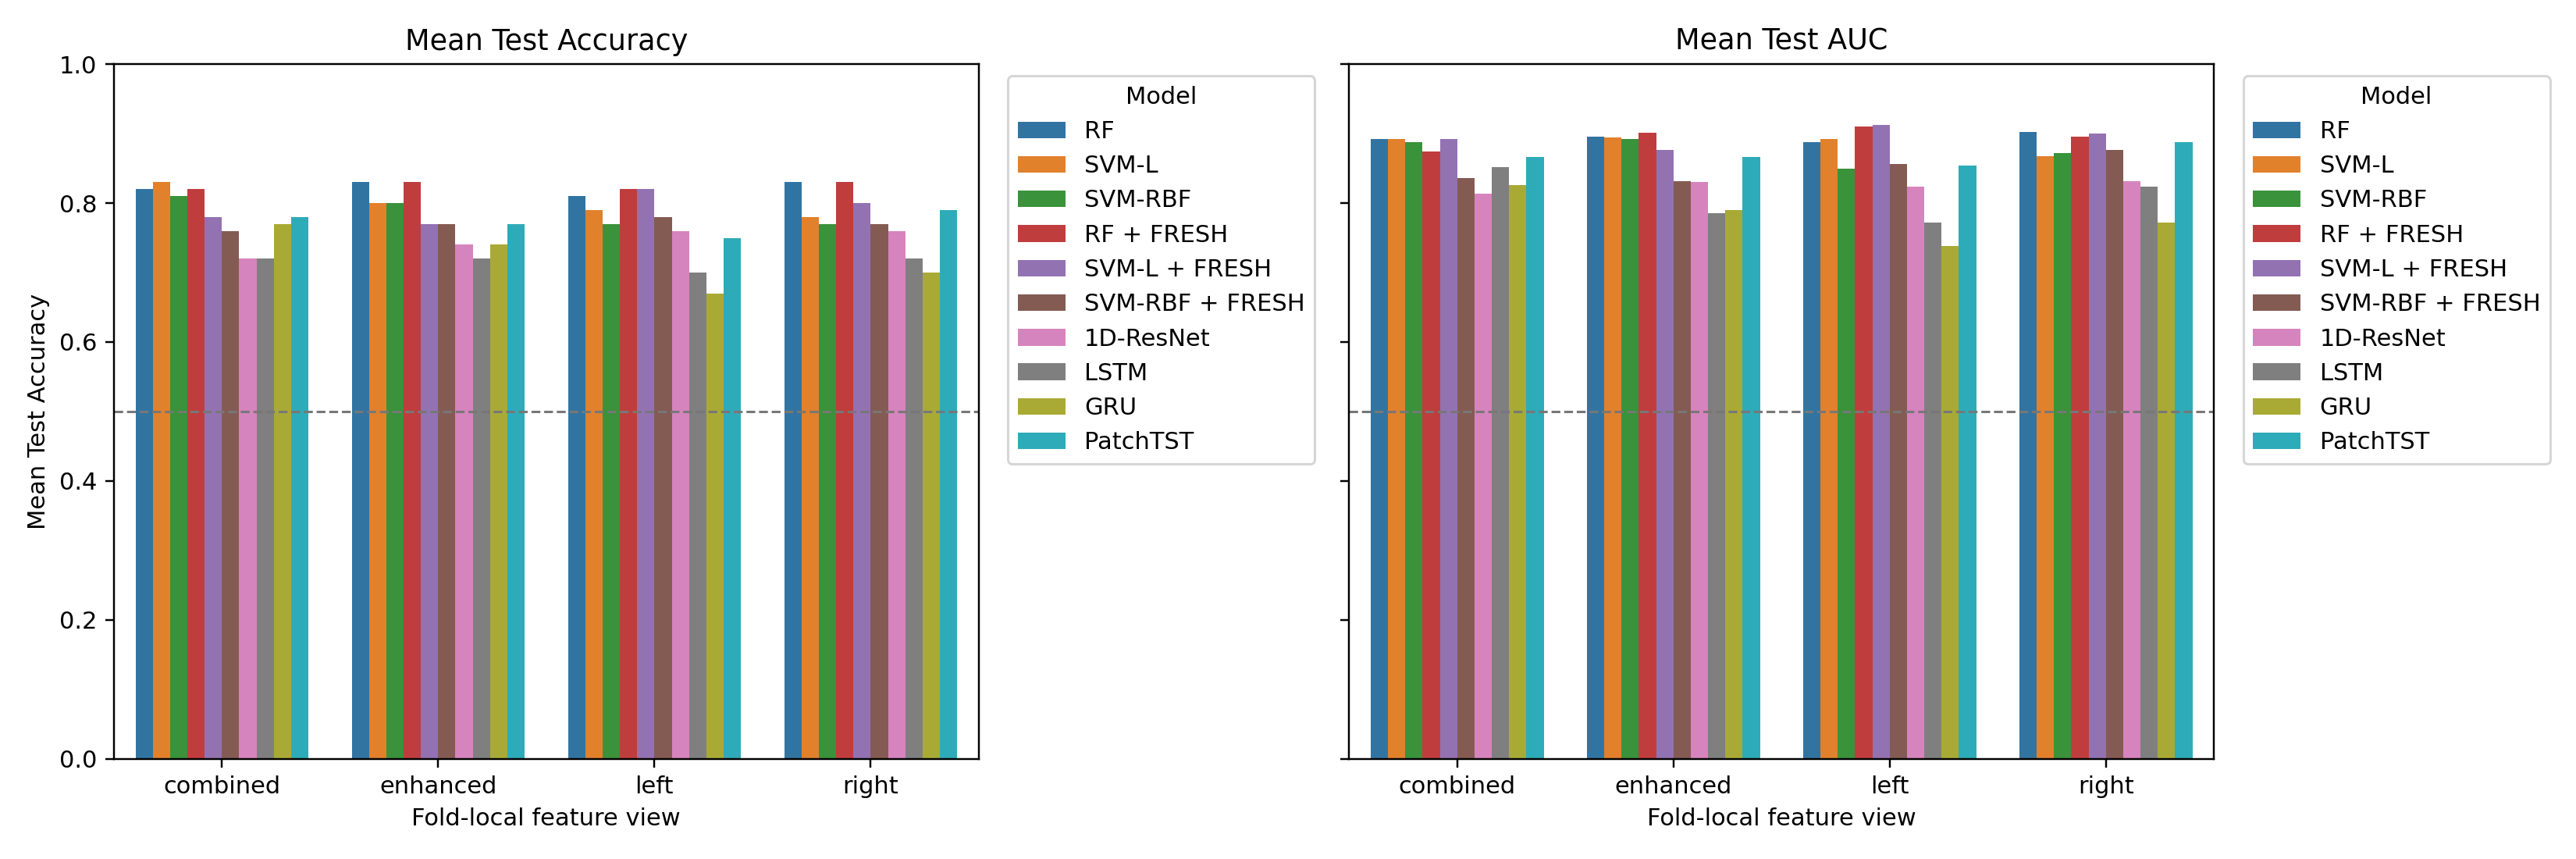

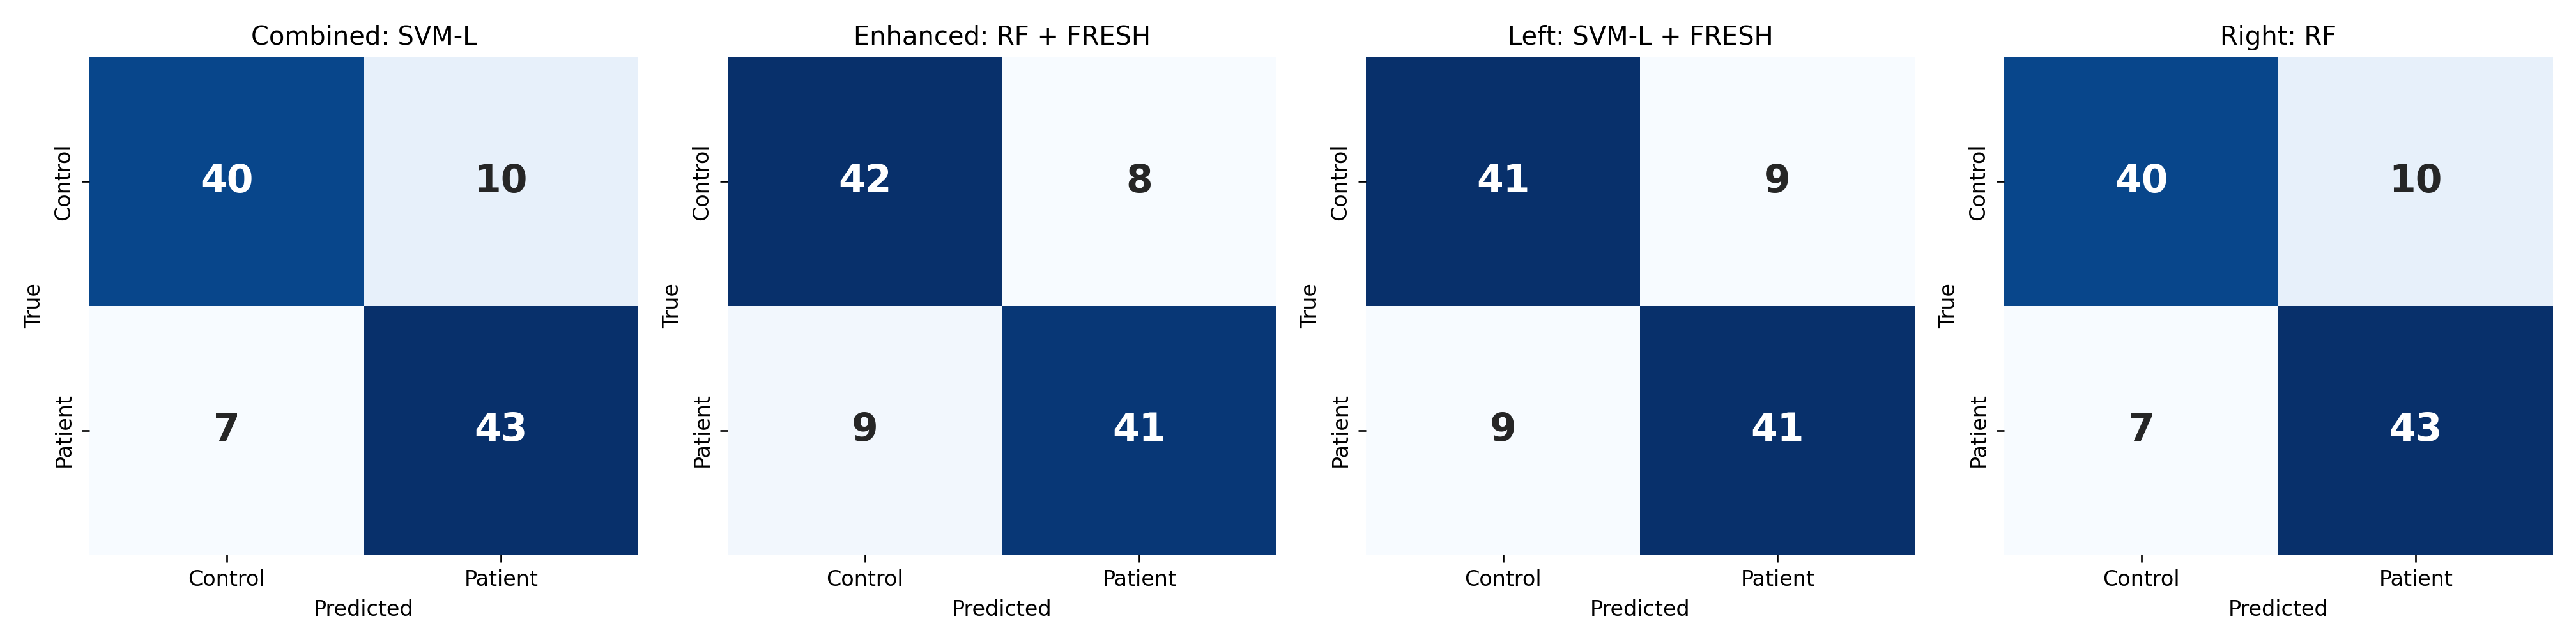

In [11]:
best_path = TABLES / "deliverable2_best_models_by_scope.csv"
if best_path.exists():
    best = pd.read_csv(best_path)
    display(best[["scope", "model", "test_accuracy_mean", "test_sensitivity_mean", "test_specificity_mean", "test_auc_mean"]])

for image_path in [FIGURES / "deliverable2_metric_summary.png", FIGURES / "deliverable2_best_confusion_matrices.png"]:
    if image_path.exists():
        display(Image(filename=str(image_path)))

## Protocol Checks

These checks verify that every reported model row is tied to exactly one train/validation/test fold and that validation, not test, is used for model selection metadata.

In [12]:
fold_metrics_path = TABLES / "deliverable2_fold_metrics.csv"
if fold_metrics_path.exists():
    fold_metrics = pd.read_csv(fold_metrics_path)
    assert set(fold_metrics["fold"]) == {f"Fold_{i}" for i in range(1, 6)}
    assert {"n_train", "n_validation", "n_test"}.issubset(fold_metrics.columns)
    assert (fold_metrics["n_train"] == 60).all()
    assert (fold_metrics["n_validation"] == 20).all()
    assert (fold_metrics["n_test"] == 20).all()
    display(fold_metrics[["family", "scope", "fold", "model", "n_train", "n_validation", "n_test", "best_params"]].head(12))
    print("Protocol checks passed for available fold metrics.")
else:
    print("Fold metrics not found yet.")

,family,scope,fold,model,n_train,n_validation,n_test,best_params
0,feature_classical,left,Fold_1,random_forest,60,20,20,"{'n_estimators': 400, 'max_depth': None, 'min_..."
1,feature_classical,left,Fold_1,linear_svm,60,20,20,"{'C': 0.01, 'k_best': 400, 'feature_source': '..."
2,feature_classical,left,Fold_1,svm_rbf,60,20,20,"{'C': 10.0, 'gamma': 0.001, 'k_best': 400, 'fe..."
3,feature_classical_tsfresh,left,Fold_1,random_forest_fresh,60,20,20,"{'n_estimators': 400, 'max_depth': None, 'min_..."
4,feature_classical_tsfresh,left,Fold_1,linear_svm_fresh,60,20,20,"{'C': 0.1, 'selector': 'tsfresh.select_feature..."
5,feature_classical_tsfresh,left,Fold_1,svm_rbf_fresh,60,20,20,"{'C': 10.0, 'gamma': 0.001, 'selector': 'tsfre..."
6,feature_classical,right,Fold_1,random_forest,60,20,20,"{'n_estimators': 400, 'max_depth': None, 'min_..."
7,feature_classical,right,Fold_1,linear_svm,60,20,20,"{'C': 0.01, 'k_best': 400, 'feature_source': '..."
8,feature_classical,right,Fold_1,svm_rbf,60,20,20,"{'C': 10.0, 'gamma': 0.001, 'k_best': 400, 'fe..."
9,feature_classical_tsfresh,right,Fold_1,random_forest_fresh,60,20,20,"{'n_estimators': 400, 'max_depth': None, 'min_..."


Protocol checks passed for available fold metrics.
